In [1]:
# laod the libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import math

In [2]:
# load the dataset
df = pd.read_csv("D:\\nexthikes solutions internship\\Data Analysis Project 3\\INDUSTRY.csv")

In [3]:
print(df.shape)
df.head()

(15000, 12)


,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
0,1,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,13-10-2025,Asia
1,2,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,01-12-2025,Europe
2,3,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,04-05-2025,North America
3,4,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,01-02-2026,North America
4,5,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,29-06-2025,Asia


In [10]:
df.columns

Index(['id', 'company_name', 'industry', 'country', 'employee_count',
       'annual_revenue_million', 'profit_margin_percent', 'founded_year',
       'customer_count', 'market_rating', 'created_date', 'region'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      15000 non-null  int64  
 1   company_name            15000 non-null  object 
 2   industry                15000 non-null  object 
 3   country                 15000 non-null  object 
 4   employee_count          15000 non-null  int64  
 5   annual_revenue_million  15000 non-null  float64
 6   profit_margin_percent   15000 non-null  float64
 7   founded_year            15000 non-null  int64  
 8   customer_count          15000 non-null  int64  
 9   market_rating           15000 non-null  float64
 10  created_date            15000 non-null  object 
 11  region                  15000 non-null  object 
dtypes: float64(3), int64(4), object(5)
memory usage: 1.4+ MB


In [12]:
df.describe()

,id,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,2606.862067,549.732707,25.012019,2004.374000,50449.251867,2.513780
std,4330.271354,1430.562513,288.244128,11.526187,8.606687,28744.638830,1.447998
min,1.000000,100.000000,50.160000,5.000000,1990.000000,500.000000,0.000000
25%,3750.750000,1379.000000,299.915000,15.050000,1997.000000,25676.250000,1.200000
50%,7500.500000,2587.000000,543.920000,24.910000,2004.000000,50726.500000,2.500000
75%,11250.250000,3839.000000,797.570000,35.100000,2012.000000,75271.250000,3.800000
max,15000.000000,5099.000000,1049.960000,45.000000,2019.000000,100495.000000,5.000000


In [10]:
df.describe(include='object')

,company_name,industry,country,created_date,region
count,15000,15000,15000,15000,15000
unique,15000,5,4,790,3
top,FinTrust_1,Finance,India,06-01-2025,North America
freq,1,3000,3750,32,7500


In [23]:
df.describe(include="all")

,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
count,15000.000000,15000,15000,15000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000,15000
unique,NaN,15000,5,4,NaN,NaN,NaN,NaN,NaN,NaN,790,3
top,NaN,FinTrust_1,Finance,India,NaN,NaN,NaN,NaN,NaN,NaN,06-01-2025,North America
freq,NaN,1,3000,3750,NaN,NaN,NaN,NaN,NaN,NaN,32,7500
mean,7500.500000,NaN,NaN,NaN,2606.862067,549.732707,25.012019,2004.374000,50449.251867,2.513780,NaN,NaN
std,4330.271354,NaN,NaN,NaN,1430.562513,288.244128,11.526187,8.606687,28744.638830,1.447998,NaN,NaN
min,1.000000,NaN,NaN,NaN,100.000000,50.160000,5.000000,1990.000000,500.000000,0.000000,NaN,NaN
25%,3750.750000,NaN,NaN,NaN,1379.000000,299.915000,15.050000,1997.000000,25676.250000,1.200000,NaN,NaN
50%,7500.500000,NaN,NaN,NaN,2587.000000,543.920000,24.910000,2004.000000,50726.500000,2.500000,NaN,NaN
75%,11250.250000,NaN,NaN,NaN,3839.000000,797.570000,35.100000,2012.000000,75271.250000,3.800000,NaN,NaN


#Data Quality

In [15]:
# Missing Values
df.isna().sum()

id                        0
company_name              0
industry                  0
country                   0
employee_count            0
annual_revenue_million    0
profit_margin_percent     0
founded_year              0
customer_count            0
market_rating             0
created_date              0
region                    0
dtype: int64

In [16]:
# Duplicate Records
df.duplicated().sum()
# no duplicate values found

np.int64(0)

In [34]:
df.drop(columns=['id'],inplace=True)

In [35]:
# inconsistency
df['company_name'].unique()
#There is no inconsistent found in company_name

array(['FinTrust_1', 'TechNova_2', 'RetailHub_3', ..., 'RetailHub_14998',
       'BuildWorks_14999', 'MediCorp_15000'], shape=(15000,), dtype=object)

In [36]:
df['industry'].unique()
#There is no inconsistent found in industry

array(['Finance', 'Technology', 'Retail', 'Manufacturing', 'Healthcare'],
      dtype=object)

In [25]:
df['country'].unique()
#There is no inconsistent found in country

array(['India', 'Germany', 'Canada', 'USA'], dtype=object)

In [26]:
df['region'].unique()
#There is no inconsistent found in region

array(['Asia', 'Europe', 'North America'], dtype=object)

In [57]:
#Data Transformation
# Convert created_date column to datetime
df['created_date'] = pd.to_datetime(df['created_date'])

# Check datatype
print(df['created_date'].dtype)

datetime64[ns]


C:\Users\Ashu\AppData\Local\Temp\ipykernel_12508\1427353944.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['created_date'] = pd.to_datetime(df['created_date'])


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      15000 non-null  int64  
 1   company_name            15000 non-null  object 
 2   industry                15000 non-null  object 
 3   country                 15000 non-null  object 
 4   employee_count          15000 non-null  int64  
 5   annual_revenue_million  15000 non-null  float64
 6   profit_margin_percent   15000 non-null  float64
 7   founded_year            15000 non-null  int64  
 8   customer_count          15000 non-null  int64  
 9   market_rating           15000 non-null  float64
 10  created_date            15000 non-null  object 
 11  region                  15000 non-null  object 
dtypes: float64(3), int64(4), object(5)
memory usage: 1.4+ MB


## Univariate Analysis
### Numerical Variables – Descriptive Statistics & Distributions

In [16]:
num_cols = ['employee_count', 'annual_revenue_million',
            'profit_margin_percent', 'founded_year',
            'customer_count', 'market_rating']
num_cols

['employee_count',
 'annual_revenue_million',
 'profit_margin_percent',
 'founded_year',
 'customer_count',
 'market_rating']

In [37]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Display columns
print(numerical_df.columns)

Index(['employee_count', 'annual_revenue_million', 'profit_margin_percent',
       'founded_year', 'customer_count', 'market_rating'],
      dtype='object')


In [8]:
# Select numerical columns
numerical_df = df.select_dtypes(include='number')

# Compute statistical measures
stats_summary = pd.DataFrame({
    'Mean': numerical_df.mean(),
    'Median': numerical_df.median(),
    'Std_Deviation': numerical_df.std(),
    'Minimum': numerical_df.min(),
    'Maximum': numerical_df.max(),
    'Skewness': numerical_df.skew(),
    'Kurtosis': numerical_df.kurt()
})

# Display result
stats_summary

,Mean,Median,Std_Deviation,Minimum,Maximum,Skewness,Kurtosis
id,7500.500000,7500.50,4330.271354,1.00,15000.00,0.000000,-1.200000
employee_count,2606.862067,2587.00,1430.562513,100.00,5099.00,0.002354,-1.187695
annual_revenue_million,549.732707,543.92,288.244128,50.16,1049.96,0.027341,-1.187059
profit_margin_percent,25.012019,24.91,11.526187,5.00,45.00,0.002560,-1.202566
founded_year,2004.374000,2004.00,8.606687,1990.00,2019.00,0.020605,-1.189609
customer_count,50449.251867,50726.50,28744.638830,500.00,100495.00,-0.004866,-1.194714
market_rating,2.513780,2.50,1.447998,0.00,5.00,-0.020033,-1.205761


# Insights:

- The dataset contains **15,000 records**, with IDs ranging from **1 to 15,000**, indicating a complete and sequential dataset.
- For all numerical features, the **mean and median values are very close**, suggesting that the distributions are well-balanced and free from significant bias.
- **Employee count** is evenly distributed across companies, with an average of approximately **2,607 employees** and no noticeable skewness.
- **Annual revenue** has a mean of **549.73 million** and a median of **543.92 million**, indicating a fairly symmetric distribution of company revenues.
- **Profit margins** are centered around **25%**, showing consistent profitability levels across organizations in the dataset.
- The average **founded year** is **2004**, with companies spanning from **1990 to 2019**, providing a balanced representation of both older and newer businesses.
- **Customer count** ranges from **500 to 100,495**, with a mean close to the median, indicating that customer distribution is relatively uniform.
- **Market ratings** are centered around **2.5 out of 5**, suggesting a balanced mix of low, medium, and high-rated companies.

## Distribution Analysis

- All features exhibit **skewness values close to zero** (between -0.02 and 0.03), indicating that the distributions are **approximately symmetric**.
- The absence of strong positive or negative skewness suggests there are **no major concentration effects or extreme directional biases** in the data.
- All variables have **negative kurtosis values (around -1.19 to -1.21)**, indicating **platykurtic distributions**.
- Platykurtic distributions are flatter than a normal distribution and contain **fewer extreme outliers**, making the dataset relatively stable for statistical analysis.
- Overall, the dataset appears **well-balanced, evenly distributed, and suitable for exploratory data analysis, visualization, and predictive modeling**.

## plot histogram for numerical columns

<Axes: xlabel='employee_count', ylabel='Count'>

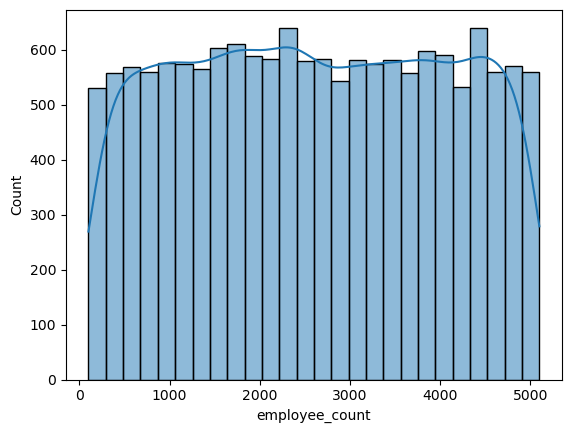

In [11]:
sns.histplot(df['employee_count'],kde=True)

### Insights: Employee Count Distribution

- **Employee count** shows a nearly symmetric distribution, with skewness close to zero, indicating a balanced spread of company sizes across the dataset.
- The distribution does not exhibit a strong bias toward either smaller or larger organizations.
- A **high standard deviation** indicates substantial variability in workforce size among companies.
- This suggests the dataset includes a mix of both small businesses and large enterprises, contributing to the wide dispersion in employee counts.

<Axes: xlabel='annual_revenue_million', ylabel='Count'>

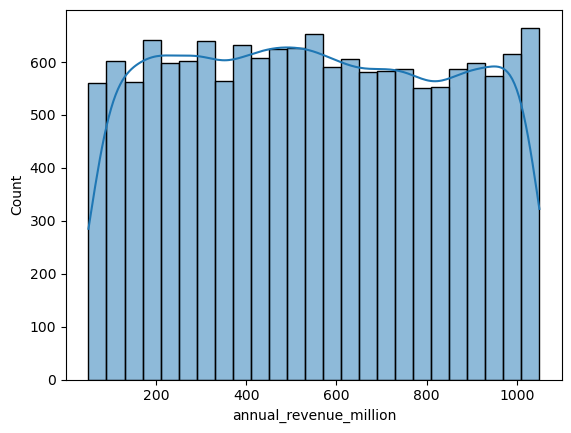

In [45]:
sns.histplot(df['annual_revenue_million'],kde=True)

## Insights
- Annual_revenue_million exhibited slight positive skewness (0.03).
- This indicates that most companies generated moderate revenue levels.
- A smaller number of companies earned comparatively higher revenue.
- The distribution is nearly symmetric, with only a slight right tail.

<Axes: xlabel='profit_margin_percent', ylabel='Count'>

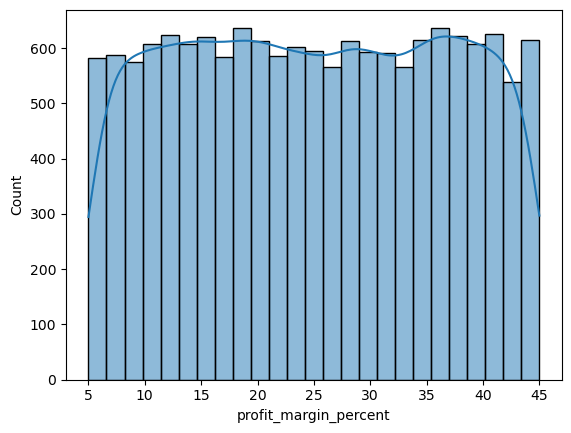

In [19]:
sns.histplot(df['profit_margin_percent'],kde=True)

### Insights: Profit Margin Percentage Distribution

- Profit margins are distributed almost uniformly between 5% and 45%.
- No specific profit margin range has a significantly higher concentration of observations.
- The distribution is approximately symmetric, indicating no noticeable skewness.
- Counts remain relatively consistent across all intervals, suggesting balanced data.
- No significant outliers or abnormal spikes are present in the dataset.
- The KDE curve is fairly flat, confirming a uniform spread of profit margin values.

<Axes: xlabel='founded_year', ylabel='Count'>

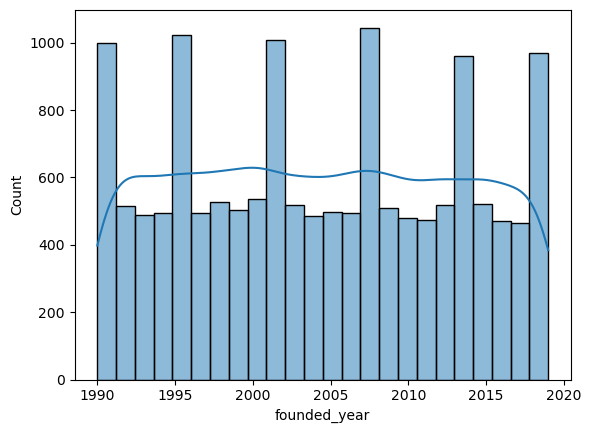

In [52]:
sns.histplot(df["founded_year"],kde=True)

### Insights:
- The **Founded Year** distribution is fairly uniform, indicating that companies from different establishment periods are well represented in the dataset.
- The skewness value is close to zero, suggesting no noticeable concentration of companies in any particular founding era.
- Both older and newer companies appear in balanced proportions, reducing temporal bias in the data.
- There is no strong tendency toward either recent startups or long-established organizations.
- This balanced distribution enhances the reliability of trend analysis and comparisons across different company age groups.

<Axes: xlabel='customer_count', ylabel='Count'>

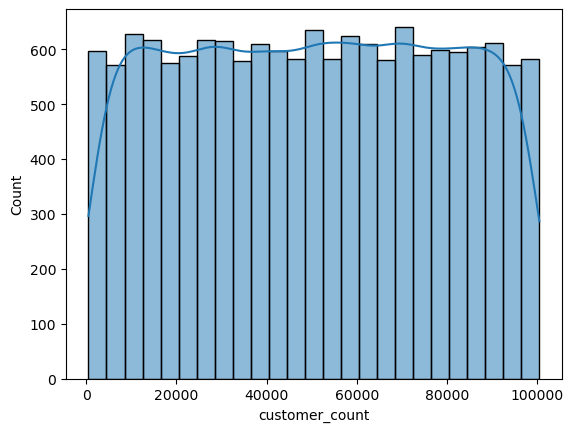

In [53]:
sns.histplot(df["customer_count"],kde=True)

### Customer Count Insights

- The wide range and high standard deviation indicate substantial variation in customer counts across companies.
- Near-zero skewness suggests that customer counts are fairly balanced and symmetrically distributed.
- The dataset includes both companies with relatively small customer bases and those serving a large number of customers, reflecting diverse market reach.

<Axes: xlabel='market_rating', ylabel='Count'>

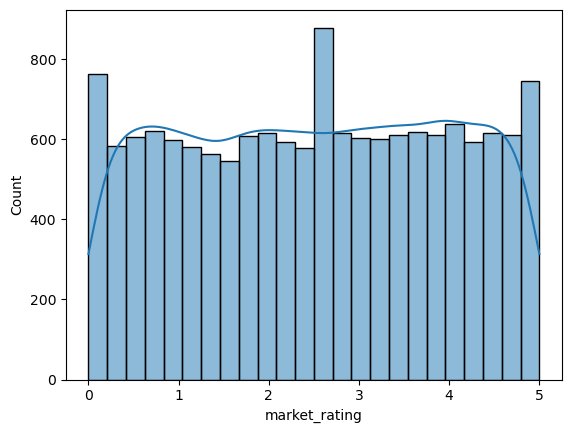

In [55]:
sns.histplot(df["market_rating"],kde=True)

### Market Rating Distribution Insights

- The **market_rating** variable exhibits a nearly symmetric distribution centered around the average rating of **2.5**, indicating a balanced spread of values.
- Ratings are distributed relatively evenly across low, medium, and high ranges, suggesting no dominant rating category.
- The absence of substantial skewness indicates that the dataset is not heavily biased toward either lower-rated or higher-rated companies.
- This balanced distribution reflects a diverse representation of company performance levels within the dataset.
- Overall, the market ratings suggest a healthy mix of companies with varying market positions and performance outcomes.

## Overall Observation

All six numerical variables exhibit very low skewness values (close to 0), indicating nearly symmetric distributions. The histograms show relatively uniform distributions across their respective ranges, suggesting balanced representation of observations without significant bias toward lower or higher values.

---

## Employee Count

- Employee counts are distributed fairly evenly between 100 and 5,000 employees.
- The skewness value of **0.00** indicates a perfectly balanced distribution.
- No particular employee size category dominates the dataset.
- Small, medium, and large organizations are represented almost equally.
- No significant outliers or extreme workforce sizes are observed.

---

## Annual Revenue (Million)

- Annual revenue values range from approximately 50 million to 1,000 million.
- The skewness value of **0.03** suggests an almost symmetric distribution with negligible right skewness.
- Companies with low, medium, and high revenues occur at similar frequencies.
- No dominant revenue segment is evident.
- The dataset captures organizations across various financial scales.

---

## Profit Margin (%)

- Profit margins are distributed between approximately 5% and 45%.
- The skewness value of **0.00** indicates a highly symmetric distribution.
- Both low-profit and high-profit companies are equally represented.
- No unusual concentration of firms at specific profit margin levels is visible.
- The distribution reflects a broad range of profitability among organizations.

---

## Founded Year

- Company founding years span from 1990 to 2019.
- The skewness value of **0.02** indicates a nearly symmetric distribution.
- Organizations founded in different decades are represented evenly.
- No specific period dominates the dataset.
- The data includes a balanced mix of older and newer companies.

---

## Customer Count

- Customer counts range from approximately 1,000 to 100,000 customers.
- The skewness value of **-0.00** indicates an almost perfectly symmetric distribution.
- Organizations with varying customer bases are represented uniformly.
- No evidence suggests that a few companies dominate the customer population.
- The dataset reflects balanced market coverage.

---

## Market Rating

- Market ratings are distributed across the full range from 0 to 5.
- The skewness value of **-0.02** indicates a nearly symmetric distribution with a very slight left skew.
- Ratings are fairly balanced between lower and higher values.
- No strong preference toward highly rated or poorly rated companies is observed.
- The distribution suggests an unbiased representation of company ratings.

---

## Key Takeaways

- All numerical variables exhibit minimal skewness (between **-0.02 and 0.03**), indicating highly balanced distributions.
- No significant outliers or heavily concentrated regions are apparent in the data.
- The dataset represents organizations across a diverse range of sizes, revenues, customer bases, profitability levels, ages, and ratings.
- Such balanced distributions are beneficial for statistical analysis and machine learning, as they reduce the likelihood of bias toward specific segments and improve model generalization.
```


## Categorical Variables – Frequency Distributions

In [21]:
categorical_cols = df.select_dtypes(include='object')

categorical_cols.head()

,company_name,industry,country,created_date,region
0,FinTrust_1,Finance,India,13-10-2025,Asia
1,TechNova_2,Technology,Germany,01-12-2025,Europe
2,RetailHub_3,Retail,Canada,04-05-2025,North America
3,BuildWorks_4,Manufacturing,USA,01-02-2026,North America
4,MediCorp_5,Healthcare,India,29-06-2025,Asia


In [62]:
# Frequency distribution for industry
print(df['industry'].value_counts())

# Frequency distribution for country
print(df['country'].value_counts())

# Frequency distribution for region
print(df['region'].value_counts())

industry
Finance          3000
Technology       3000
Retail           3000
Manufacturing    3000
Healthcare       3000
Name: count, dtype: int64
country
India      3750
Germany    3750
Canada     3750
USA        3750
Name: count, dtype: int64
region
North America    7500
Asia             3750
Europe           3750
Name: count, dtype: int64


               Frequency  Percentage
industry                            
Finance             3000        20.0
Technology          3000        20.0
Retail              3000        20.0
Manufacturing       3000        20.0
Healthcare          3000        20.0


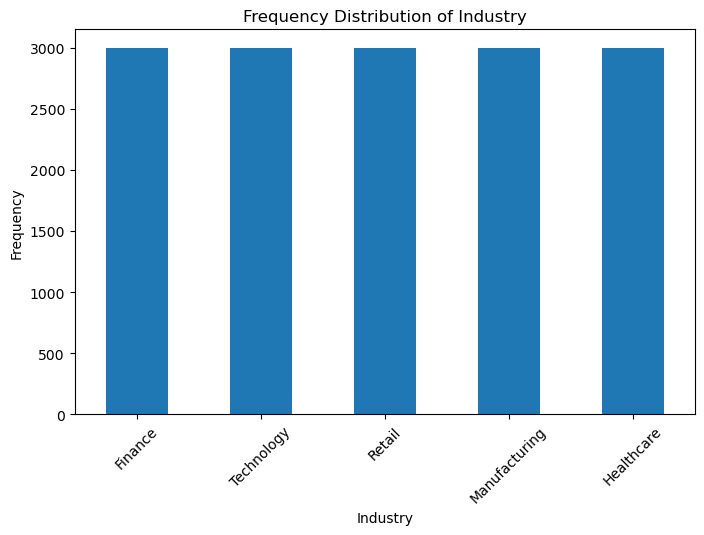

In [26]:
#Industry frequency table
industry_freq = pd.DataFrame({
    'Frequency': df['industry'].value_counts(),
    'Percentage': round(df['industry'].value_counts(normalize=True) * 100, 2)
})

print(industry_freq)

#Chart Visualization using Matplotlib

df['industry'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title('Frequency Distribution of Industry')
plt.xlabel('Industry')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

         Frequency  Percentage
country                       
India         3750        25.0
Germany       3750        25.0
Canada        3750        25.0
USA           3750        25.0


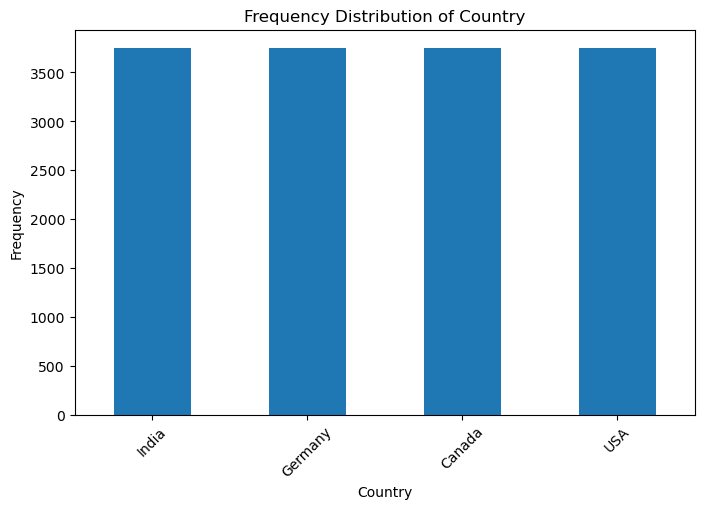

In [7]:
# Country frequency table
country_freq = pd.DataFrame({
    'Frequency': df['country'].value_counts(),
    'Percentage': round(df['country'].value_counts(normalize=True) * 100, 2)
})

print(country_freq)

#Chart Visualization using Matplotlib
df['country'].value_counts().plot(kind='bar', figsize=(8,5))
plt.title('Frequency Distribution of Country')
plt.xlabel('Country')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

               Frequency  Percentage
region                              
North America       7500        50.0
Asia                3750        25.0
Europe              3750        25.0


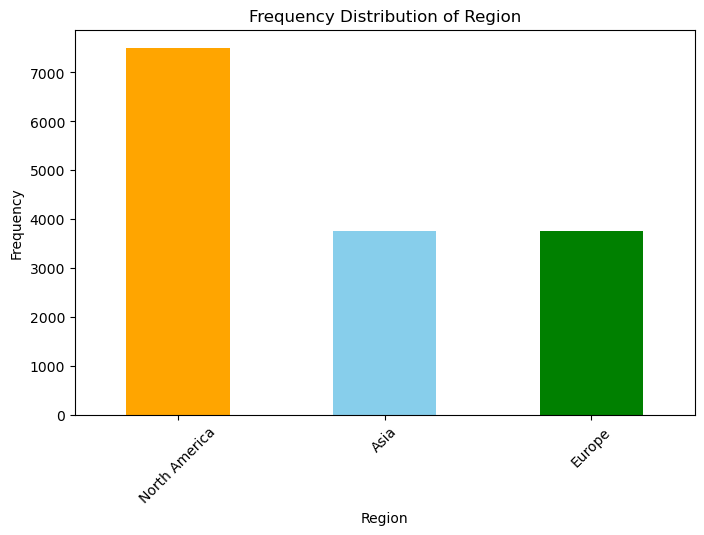

In [24]:
# Region frequency table
region_freq = pd.DataFrame({
    'Frequency': df['region'].value_counts(),
    'Percentage': round(df['region'].value_counts(normalize=True) * 100, 2)
})

print(region_freq)

#Chart Visualization using Matplotlib
region_counts = df['region'].value_counts()

colors = ['orange', 'skyblue', 'green']

region_counts.plot(
    kind='bar',
    figsize=(8,5),
    color=colors
)
plt.title('Frequency Distribution of Region')
plt.xlabel('Region')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

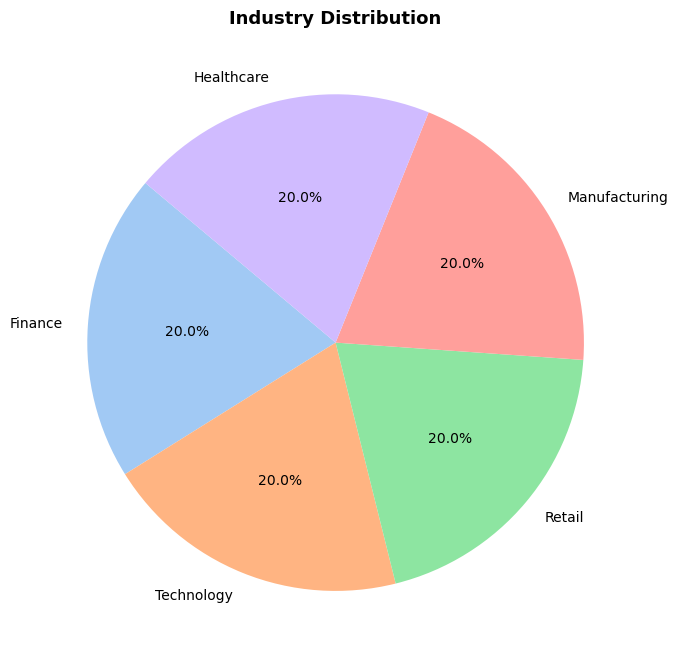

In [5]:
# Pie chart – Industry share
fig, ax = plt.subplots(figsize=(7, 7))
industry_counts = df['industry'].value_counts()
ax.pie(industry_counts, labels=industry_counts.index, autopct='%1.1f%%',
       startangle=140, colors=sns.color_palette('pastel'))
ax.set_title('Industry Distribution', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()


## Univariate Analysis Insights

### Industry Distribution
- All five industries (**Finance, Technology, Retail, Manufacturing, and Healthcare**) contain **3,000 companies each**.
- The industry distribution is perfectly balanced, indicating equal representation across all sectors.
- No industry dominates the dataset, minimizing the risk of industry-specific bias in subsequent analyses.

### Country Distribution
- The four countries (**USA, Canada, Germany, and India**) each have **3,750 companies**.
- The dataset shows a uniform distribution across countries.
- This balanced representation enables reliable comparisons between countries without skewed results.

### Region Distribution
- **North America** has the highest number of companies (**7,500**), accounting for **50% of the dataset**.
- **Asia** and **Europe** each contain **3,750 companies**, representing **25% of the dataset each**.
- The regional distribution is moderately imbalanced, with North America having twice as many companies as Asia and Europe.

### Key Takeaways
- The dataset is **well-balanced across Industry and Country categories**, ensuring fair and unbiased analysis.
- **Regional representation is uneven**, with North America contributing the largest share of observations.
- Regional trends may therefore be more influenced by North American companies and should be interpreted accordingly.

## Outlier Detection

In [29]:
# Select numerical columns
numerical_df = df.select_dtypes(include='number')
numerical_df.head()

,id,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating
0,1,535,539.38,40.42,2010,81191,0.7
1,2,3806,852.42,39.55,2010,92162,3.4
2,3,2779,257.11,23.68,1996,27532,2.9
3,4,835,309.14,31.31,1993,90815,0.9
4,5,4490,988.68,43.65,1996,850,0.5


In [37]:
#IQR Method
iqr_results = {}
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    iqr_results[col] = {'Q1': round(Q1,2), 'Q3': round(Q3,2),
                        'IQR': round(IQR,2), 'Lower Bound': round(lower,2),
                        'Upper Bound': round(upper,2), 'Outliers': n_out}

pd.DataFrame(iqr_results).T


,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers
employee_count,1379.00,3839.00,2460.00,-2311.00,7529.00,0.0
annual_revenue_million,299.92,797.57,497.66,-446.57,1544.05,0.0
profit_margin_percent,15.05,35.10,20.05,-15.03,65.18,0.0
founded_year,1997.00,2012.00,15.00,1974.50,2034.50,0.0
customer_count,25676.25,75271.25,49595.00,-48716.25,149663.75,0.0
market_rating,1.20,3.80,2.60,-2.70,7.70,0.0


## Z-Score Method

In [5]:
z_results = {}
for col in num_cols:
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    z_results[col] = (z_scores > 3).sum()

z_df = pd.DataFrame.from_dict(z_results, orient='index', columns=['Z-score Outliers (|z|>3)'])
z_df


,Z-score Outliers (|z|>3)
employee_count,0
annual_revenue_million,0
profit_margin_percent,0
founded_year,0
customer_count,0
market_rating,0


## Outlier Detetction - Boxplots

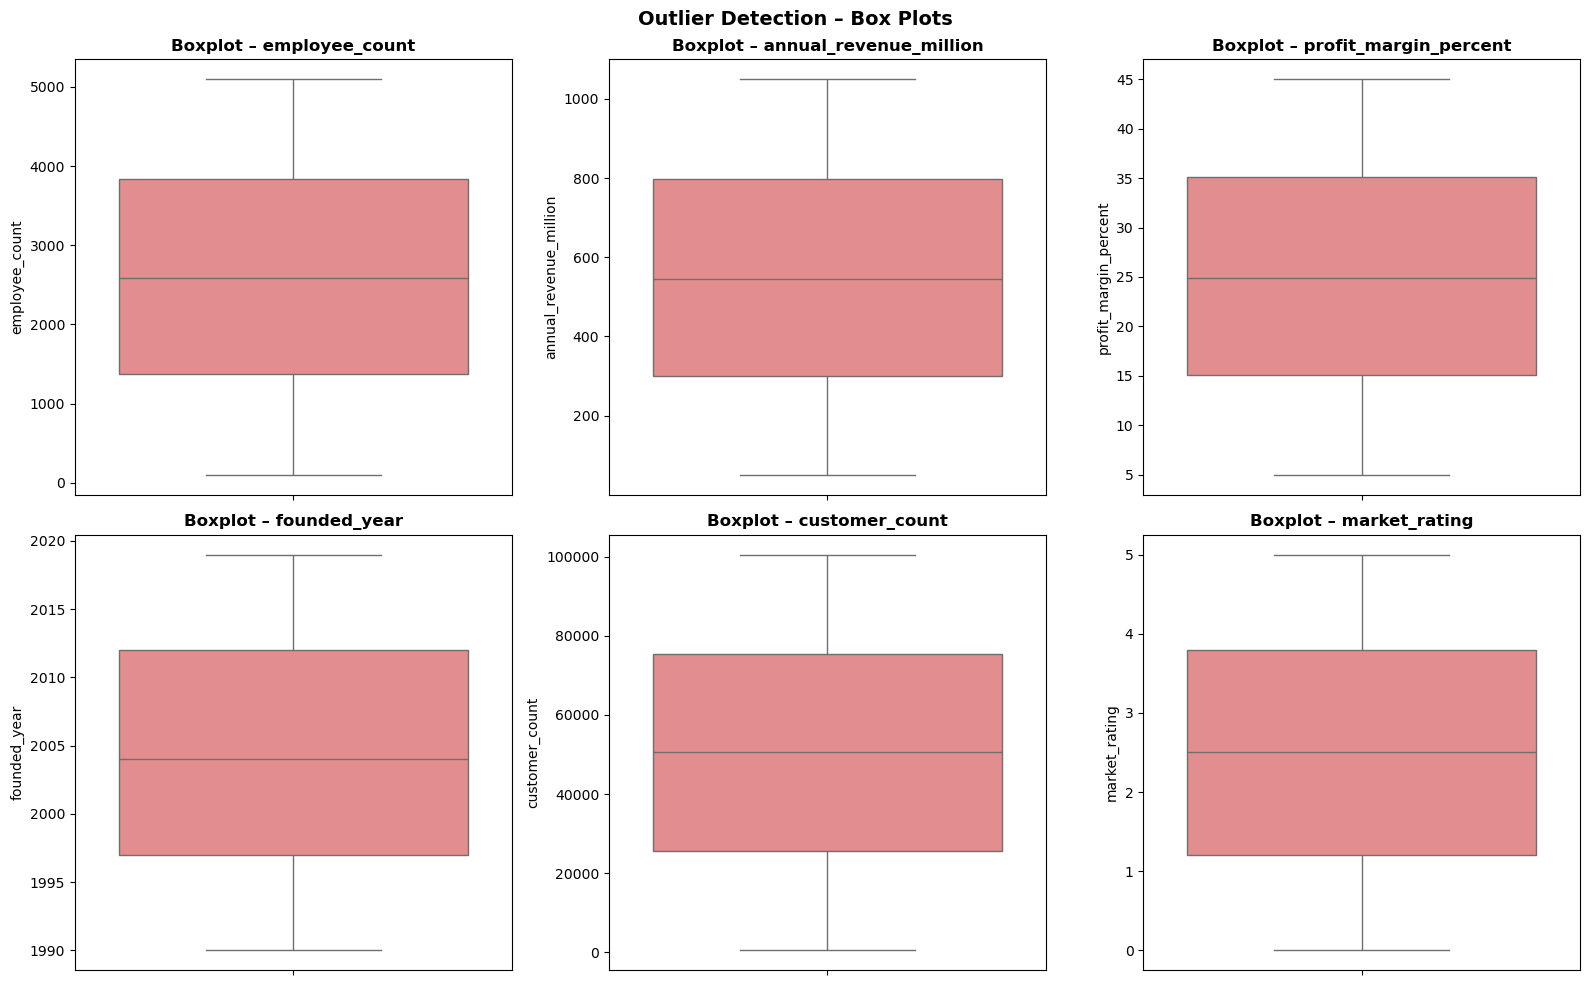

In [55]:
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot – {col}', fontweight='bold')
    axes[i].set_ylabel(col)

# Remove empty subplots
for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Outlier Detection – Box Plots', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Insights from Outlier Detection – Box Plots

### Employee Count
- Median employee count is approximately 2,600.
- Most companies have between 1,350 and 3,850 employees.
- Employee sizes vary considerably across organizations.
- No significant outliers are detected.

### Annual Revenue (Million)
- Median annual revenue is around 550 million.
- Most companies generate revenue between 300 and 800 million.
- Revenue distribution is fairly balanced.
- No extreme revenue outliers are present.

### Profit Margin (%)
- Median profit margin is approximately 25%.
- Most companies have profit margins between 15% and 35%.
- Profitability is evenly distributed across companies.
- No notable outliers are observed.

### Founded Year
- Median founding year is around 2004.
- Most companies were established between 1997 and 2012.
- The dataset includes both mature and relatively new companies.
- No outliers are present.

### Customer Count
- Median customer count is approximately 50,000.
- Most companies serve between 25,000 and 75,000 customers.
- Customer base sizes show moderate variability.
- No significant outliers are detected.

### Market Rating
- Median market rating is around 2.5.
- Most ratings lie between 1.2 and 3.8.
- Ratings are fairly evenly distributed.
- No unusual rating outliers are observed.

### Overall Observation
- None of the variables exhibit significant outliers.
- Distributions appear balanced and relatively symmetric.
- The dataset is suitable for further analysis without requiring major outlier treatment.

## Bivariate Analysis

##  Numerical vs Numerical

In [117]:
# Select only numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Display numerical columns
print(num_cols)

['employee_count', 'annual_revenue_million', 'profit_margin_percent', 'founded_year', 'customer_count', 'market_rating']


## Numerical vs Numerical – Scatter Plots

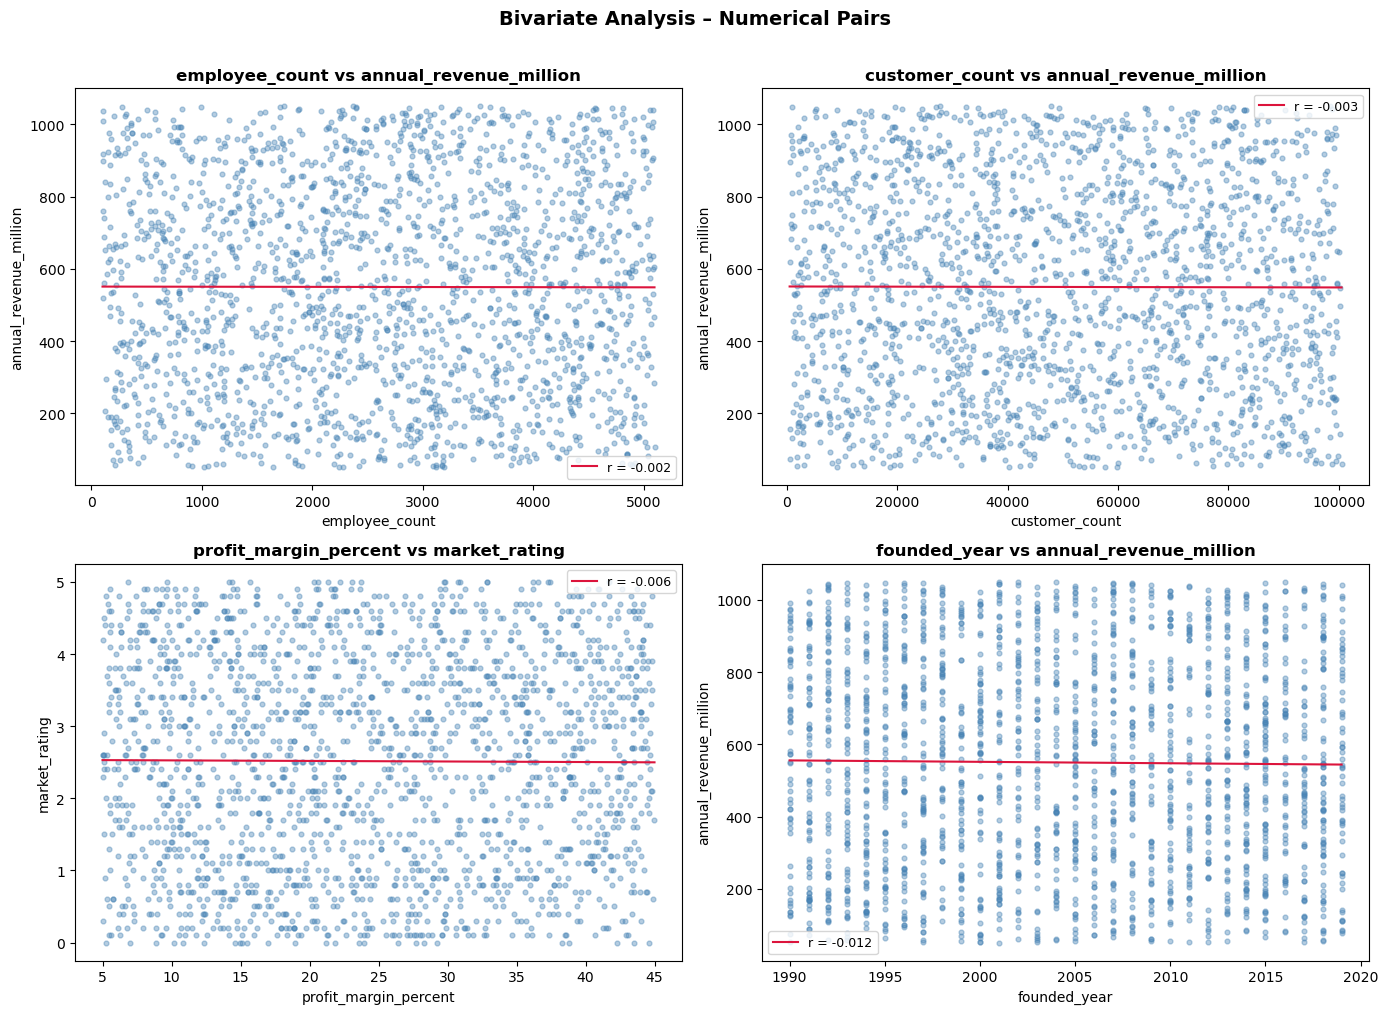

In [56]:
pairs = [
    ('employee_count',  'annual_revenue_million'),
    ('customer_count',  'annual_revenue_million'),
    ('profit_margin_percent', 'market_rating'),
    ('founded_year',    'annual_revenue_million'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (x, y) in zip(axes, pairs):
    sample = df.sample(min(2000, len(df)), random_state=42)
    ax.scatter(sample[x], sample[y], alpha=0.4, s=12, color='steelblue')
    m, b, r, p, _ = stats.linregress(df[x].dropna(), df[y].dropna())
    x_line = np.linspace(df[x].min(), df[x].max(), 200)
    ax.plot(x_line, m * x_line + b, color='crimson', lw=1.5, label=f'r = {r:.3f}')
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Bivariate Analysis – Numerical Pairs', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Bivariate Analysis Insights

- **Employee Count vs Annual Revenue (r = -0.002):**
  - No significant relationship exists between employee count and annual revenue.
  - Companies of all sizes generate a wide range of revenues.
  - Workforce size alone is not a strong predictor of revenue.

- **Customer Count vs Annual Revenue (r = -0.003):**
  - Customer count shows virtually no correlation with annual revenue.
  - Revenue varies considerably across all customer count levels.
  - A larger customer base does not necessarily lead to higher revenue.

- **Profit Margin (%) vs Market Rating (r = -0.006):**
  - Profit margin has no meaningful relationship with market rating.
  - Companies with varying profitability levels receive similar ratings.
  - Market ratings are likely influenced by factors beyond profitability.

- **Founded Year vs Annual Revenue (r = -0.012):**
  - Company age has an extremely weak relationship with annual revenue.
  - Both older and newer companies display similar revenue distributions.
  - Being established earlier does not guarantee higher revenue.

### Overall Conclusion
- All variable pairs show near-zero correlation coefficients (|r| < 0.02).
- No strong linear relationships are observed among the analyzed numerical variables.
- Business performance metrics appear to be influenced by multiple factors rather than a single variable.
- Further multivariate and non-linear analysis may reveal deeper insights.

## Correlation Matrix Analysis

In [18]:
# Select numerical columns
contVar = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
corrdf = df[contVar].corr(method='pearson')
corrdf

,id,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating
id,1.000000,0.018014,0.002347,0.010109,-0.000258,-0.005306,-0.003658
employee_count,0.018014,1.000000,-0.002043,-0.002724,0.021180,-0.012431,-0.009352
annual_revenue_million,0.002347,-0.002043,1.000000,-0.003120,-0.011840,-0.002673,0.014639
profit_margin_percent,0.010109,-0.002724,-0.003120,1.000000,0.012379,0.011347,-0.006096
founded_year,-0.000258,0.021180,-0.011840,0.012379,1.000000,-0.008447,0.007468
customer_count,-0.005306,-0.012431,-0.002673,0.011347,-0.008447,1.000000,-0.004750
market_rating,-0.003658,-0.009352,0.014639,-0.006096,0.007468,-0.004750,1.000000


<Axes: >

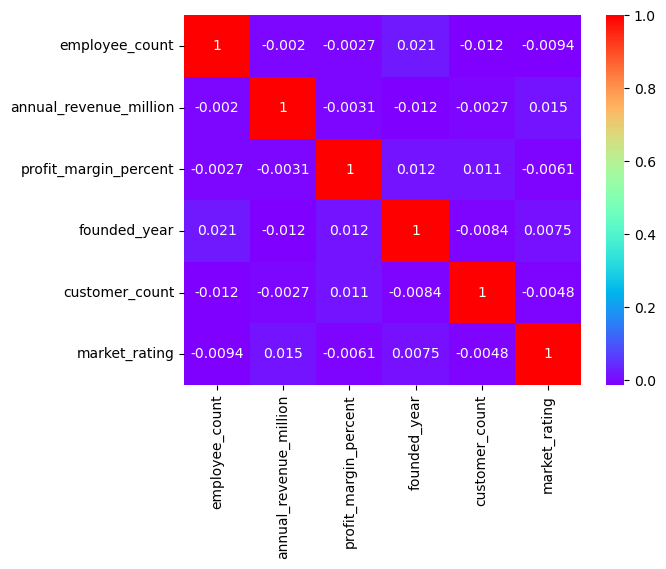

In [130]:
# Heatmap
sns.heatmap(corrdf,annot=True,cmap='rainbow')

## 📊 Correlation Heatmap Insights

### 1. No Strong Correlations Observed
- All correlation coefficients are very close to **0**, indicating extremely weak linear relationships between the variables.
- None of the features show a strong positive or negative correlation with each other.

### 2. Employee Count Has Minimal Impact on Other Variables
- Employee count exhibits negligible correlations with annual revenue, profit margin, customer count, and market rating.
- This suggests that larger workforces do not necessarily translate into higher revenue, profitability, or customer acquisition in this dataset.

### 3. Annual Revenue is Independent of Most Factors
- Annual revenue has almost no correlation with employee count, profit margin, founded year, or customer count.
- A very weak positive correlation exists with market rating (**0.015**), but it is too small to be practically significant.

### 4. Profit Margin Shows Weak Relationships
- Profit margin is weakly correlated with founded year (**0.012**) and customer count (**0.011**).
- These values are close to zero, indicating little to no meaningful association.

### 5. Company Age Does Not Influence Performance
- Founded year has negligible correlations with revenue, customer count, profit margin, and market rating.
- Older companies do not appear to perform significantly differently from newer companies based on the available metrics.

### 6. Market Rating is Largely Independent
- Market rating has near-zero correlations with all other variables.
- This suggests ratings may be influenced by factors not included in the dataset.

### 🔑 Key Takeaways
- The dataset does not exhibit strong linear relationships among the numerical variables.
- No single feature appears to be a reliable predictor of another based on correlation analysis.
- The low correlation values indicate that business performance metrics may be influenced by multiple independent factors.
- Further analysis using advanced techniques (feature engineering, segmentation, or non-linear models) may be required to uncover hidden patterns.

In [ ]:
#Numerical vs Categorical Analysis

INDUSTRY vs AVERAGE ANNUAL REVENUE

industry
Retail           556.609343
Finance          552.823690
Technology       550.198027
Manufacturing    545.575197
Healthcare       543.457277
Name: annual_revenue_million, dtype: float64


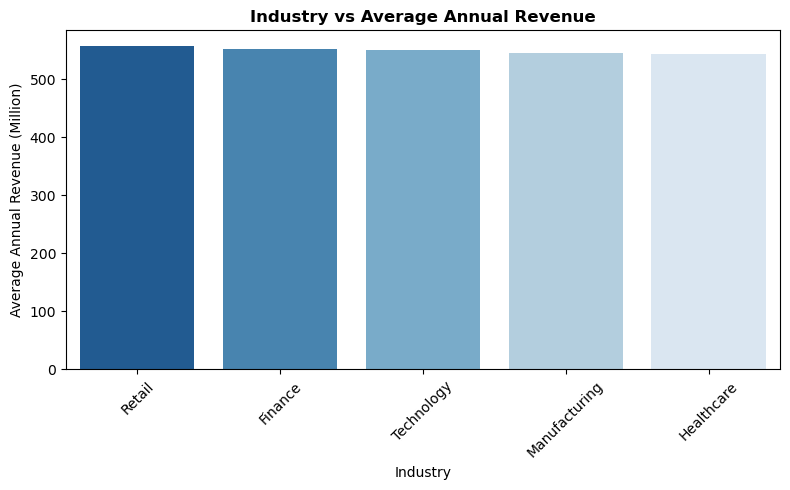

In [11]:
# Industry vs Average Annual Revenue
industry_revenue = df.groupby('industry')['annual_revenue_million'].mean().sort_values(ascending=False)
print("INDUSTRY vs AVERAGE ANNUAL REVENUE\n")
print(industry_revenue)

#Chart Visualization using Seaborn
plt.figure(figsize=(8,5))

sns.barplot(
    x=industry_revenue.index,
    y=industry_revenue.values,
    hue=industry_revenue.index,
    palette='Blues_r',
    legend=False
)

plt.title("Industry vs Average Annual Revenue", fontweight='bold')
plt.xlabel("Industry")
plt.ylabel("Average Annual Revenue (Million)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

REGION vs AVERAGE EMPLOYEE COUNT
region
Europe           2634.276533
Asia             2600.321333
North America    2596.425200
Name: employee_count, dtype: float64


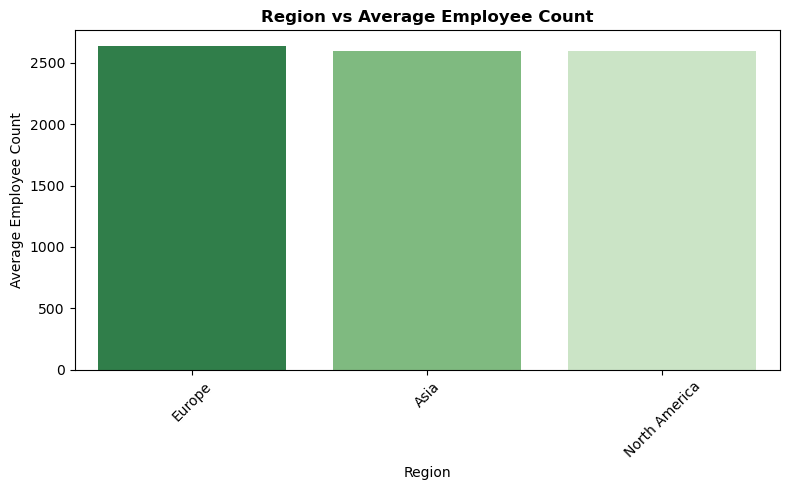

In [15]:
# Region vs Average Employee Count
region_employee = df.groupby('region')['employee_count'].mean().sort_values(ascending=False)
print("REGION vs AVERAGE EMPLOYEE COUNT")
print(region_employee)

#Chart Visualization using seaborn
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_employee.index,
    y=region_employee.values,
    hue=region_employee.index,
    palette='Greens_r',
    legend=False

)

plt.title("Region vs Average Employee Count", fontweight='bold')
plt.xlabel("Region")
plt.ylabel("Average Employee Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

COUNTRY vs AVERAGE MARKET RATING
country
Germany    2.521973
USA        2.518267
Canada     2.511147
India      2.503733
Name: market_rating, dtype: float64


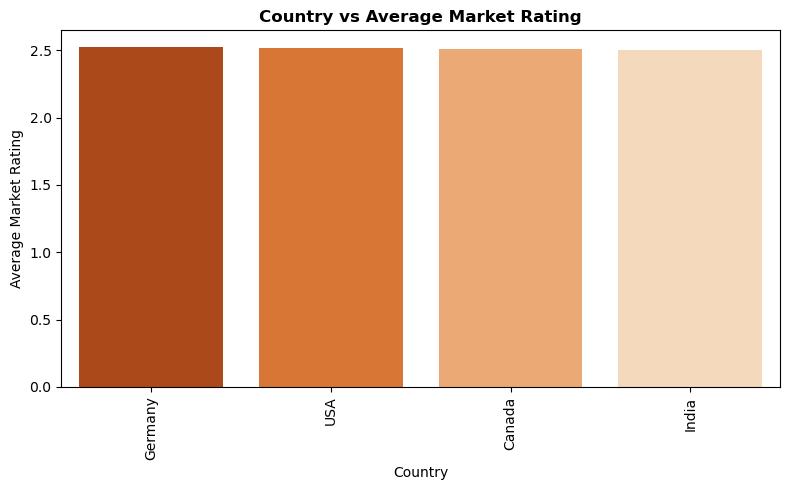

In [16]:
# Country vs Average Market Rating
country_rating = df.groupby('country')['market_rating'].mean().sort_values(ascending=False)

print("COUNTRY vs AVERAGE MARKET RATING")
print(country_rating)


#Chart Visualization using seaborn
plt.figure(figsize=(8,5))
sns.barplot(
    x=country_rating.index,
    y=country_rating.values,
    hue=country_rating.index,
    palette='Oranges_r',
    legend=False
    
)

plt.title("Country vs Average Market Rating", fontweight='bold')
plt.xlabel("Country")
plt.ylabel("Average Market Rating")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## 📊 Bivariate Analysis Insights
## Numerical vs Categorical Values

### 1. Average Annual Revenue by Industry
- Retail generates the highest average annual revenue among all industries.
- Finance and Technology closely follow Retail, indicating strong revenue performance.
- Manufacturing and Healthcare have comparatively lower average revenues.
- Revenue distribution across industries is fairly balanced, with no major disparities.

### 2. Average Employee Count by Region
- Europe has the highest average employee count, suggesting larger workforce sizes.
- North America and Asia show very similar employee counts.
- The differences in workforce size across regions are minimal, indicating a relatively balanced employee distribution globally.

### 3. Average Profit Margin by Industry
- Finance records the highest average profit margin (~25%), making it the most profitable industry.
- Retail ranks second in profitability while also leading in revenue generation.
- Technology and Healthcare maintain competitive profit margins.
- Manufacturing has the lowest average profit margin, which may indicate higher operational costs.

### 🔑 Overall Business Insights
- Retail is the strongest performer in terms of revenue generation while maintaining high profitability.
- Finance demonstrates excellent profitability despite not having the highest revenue.
- Europe appears to host the largest workforce among the regions analyzed.
- Manufacturing may benefit from cost optimization strategies to improve profit margins.
- Overall, industry performance is relatively balanced, with no single sector overwhelmingly dominating the market.

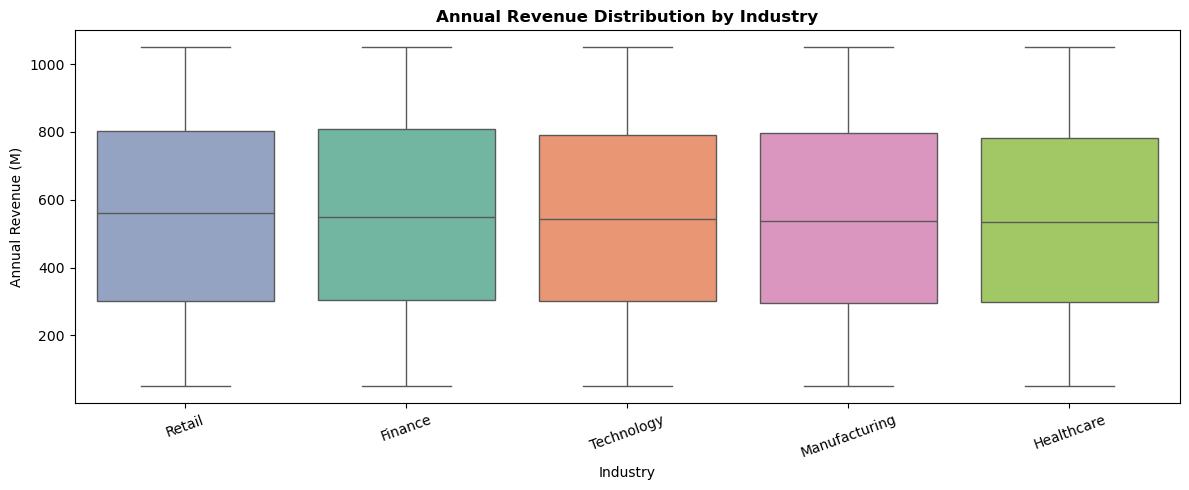

In [6]:
# Box plots: annual revenue by industry
plt.figure(figsize=(12, 5))

order = df.groupby('industry')['annual_revenue_million'].median()\
          .sort_values(ascending=False).index

sns.boxplot(
    data=df,
    x='industry',
    y='annual_revenue_million',
    hue='industry',
    order=order,
    palette='Set2',
    legend=False
)

plt.title('Annual Revenue Distribution by Industry', fontweight='bold')
plt.xlabel('Industry')
plt.ylabel('Annual Revenue (M)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 📊 Annual Revenue Distribution by Industry – Insights

### 1. Revenue Distribution is Consistent Across Industries
- All industries exhibit a very similar distribution of annual revenue.
- The median revenue for each industry lies around **$540M–$570M**, indicating comparable financial performance.

### 2. Wide Revenue Variability Within Industries
- Each industry shows a broad range of revenues, spanning approximately **$50M to $1,050M**.
- This suggests the presence of both small and large companies within every industry.

### 3. Similar Spread Across Categories
- The interquartile range (IQR) is nearly identical for all industries.
- This indicates that revenue variability is consistent regardless of industry type.

### 4. No Significant Outliers Detected
- The boxplots do not display any prominent outliers.
- Revenue values appear to be well distributed without extreme deviations.

### 5. Retail and Finance Slightly Lead
- Retail and Finance show marginally higher median revenues compared to the other industries.
- However, the differences are small and not substantial enough to indicate a dominant industry.

### Key Takeaways
- Revenue patterns are remarkably similar across all industries.
- Companies within each industry experience comparable levels of revenue variation.
- No industry demonstrates exceptionally high or low revenue performance relative to others.
- The absence of major outliers suggests a balanced and stable revenue distribution across the dataset.

# Multivariate Analysis 

 Industry × Revenue × Employee Count 
               annual_revenue_million  employee_count
industry                                             
Finance                    552.823690     2621.878333
Healthcare                 543.457277     2610.893667
Manufacturing              545.575197     2582.221000
Retail                     556.609343     2608.425000
Technology                 550.198027     2610.892333


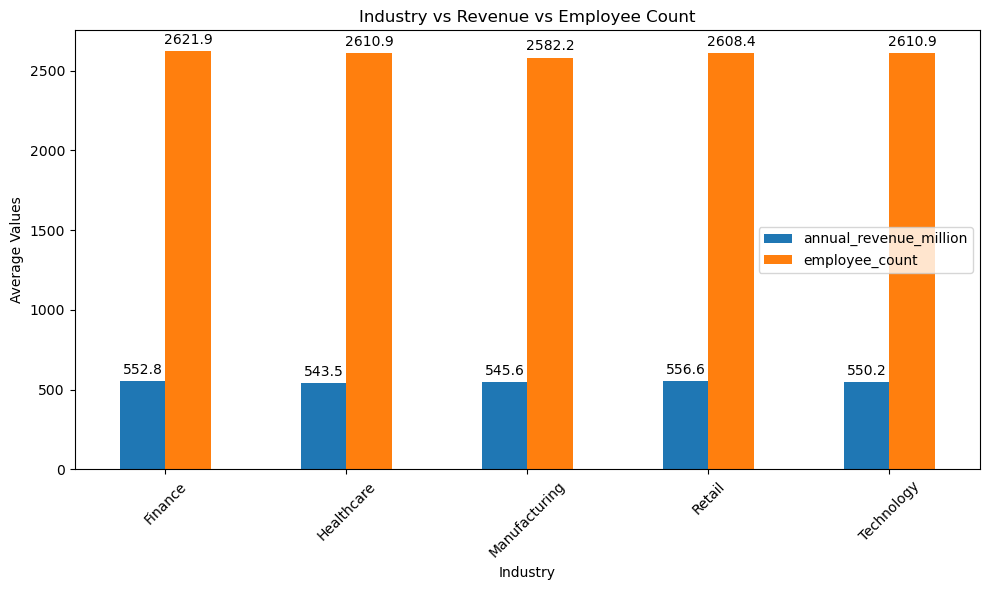

In [7]:
# Industry × Revenue × Employee Count
industry_multi = df.groupby('industry')[['annual_revenue_million', 'employee_count']].mean()

print(" Industry × Revenue × Employee Count ")
print(industry_multi)

# Chart Visualization
ax = industry_multi.plot(kind='bar', figsize=(10,6))

plt.title("Industry vs Revenue vs Employee Count")
plt.xlabel("Industry")
plt.ylabel("Average Values")
plt.xticks(rotation=45)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3)

plt.tight_layout()
plt.show()


### Insights: Industry vs Revenue vs Employee Count

- **Retail** generates the **highest average annual revenue** (~556.6 million), indicating strong sales performance compared to other industries.
- **Finance** has the **largest average workforce** (~2,621 employees), suggesting a higher dependence on human resources.
- **Manufacturing** records the **lowest average employee count** (~2,582 employees) while maintaining a competitive revenue level (~545.6 million), indicating efficient workforce utilization.
- **Healthcare** has the **lowest average revenue** (~543.5 million) among the industries analyzed, despite having a relatively large employee base.
- **Technology** shows strong performance with an average revenue of ~550.2 million and an employee count of ~2,611, reflecting a balance between workforce size and revenue generation.
- The differences in **employee count are relatively small** across industries (approximately 2,582–2,622 employees), indicating a fairly uniform workforce distribution.
- Revenue values are also **closely grouped** (approximately 543–557 million), suggesting consistent financial performance across industries.
- Industries with similar employee counts generate different levels of revenue, implying that **workforce size alone does not determine revenue performance**.
- Overall, **Retail appears to be the most revenue-efficient industry**, while **Finance employs the largest workforce**, highlighting different operational strategies across sectors.

 Region × Market Rating × Profit Margin 
               market_rating  profit_margin_percent
region                                             
Asia                2.503733              25.077557
Europe              2.521973              25.018747
North America       2.514707              24.975887


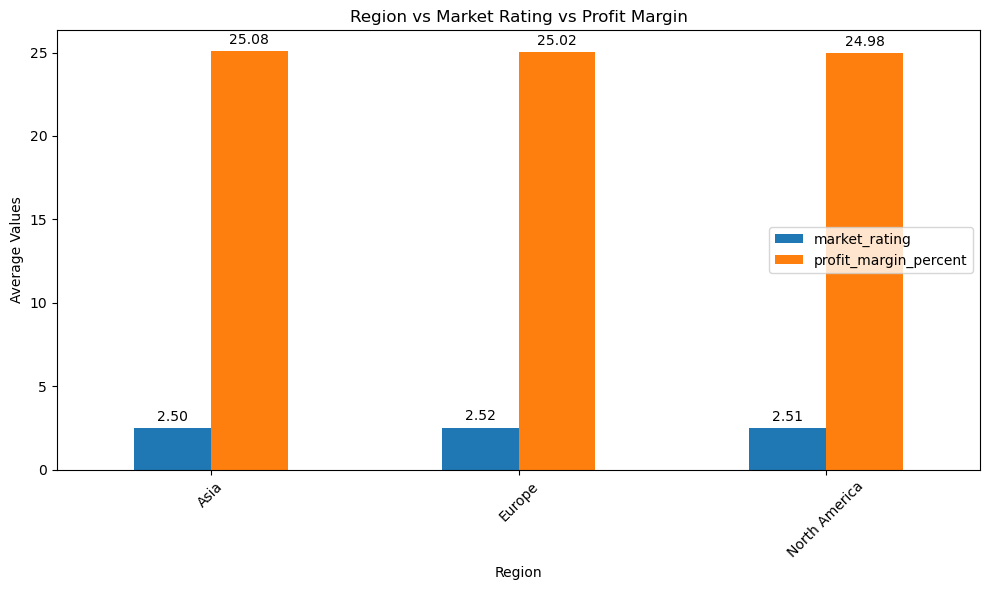

In [8]:
# 2. Region × Market Rating × Profit Margin
region_multi = df.groupby('region')[['market_rating', 'profit_margin_percent']].mean()
print(" Region × Market Rating × Profit Margin ")
print(region_multi)

#Chart Visualization using Matplotlib
ax = region_multi.plot(kind='bar', figsize=(10,6))

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.title("Region vs Market Rating vs Profit Margin")
plt.xlabel("Region")
plt.ylabel("Average Values")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insights: Region vs Market Rating vs Profit Margin

- **Europe** has the **highest average market rating** (2.52), indicating slightly better market performance compared to the other regions.
- **Asia** records the **highest average profit margin** (25.08%), making it the most profitable region despite having the lowest market rating (2.50).
- **North America** has a market rating of **2.51** and a profit margin of **24.98%**, showing balanced but slightly lower profitability than Asia and Europe.
- The differences in **market ratings are minimal** (2.50–2.52), suggesting that customer or market perceptions are fairly consistent across all regions.
- Similarly, **profit margins are very close** (24.98%–25.08%), indicating stable profitability regardless of region.
- The region with the highest market rating (**Europe**) does not have the highest profit margin, suggesting that higher ratings do not necessarily lead to greater profitability.
- Overall, the graph indicates a **strong consistency in both market performance and profit margins** across Asia, Europe, and North America, with only marginal regional variations.

 Country × Customer Count × Revenue 
         customer_count  annual_revenue_million
country                                        
Canada     51453.220533              548.375403
Germany    50197.027200              545.775243
India      49993.631200              551.872211
USA        50153.128533              552.907971


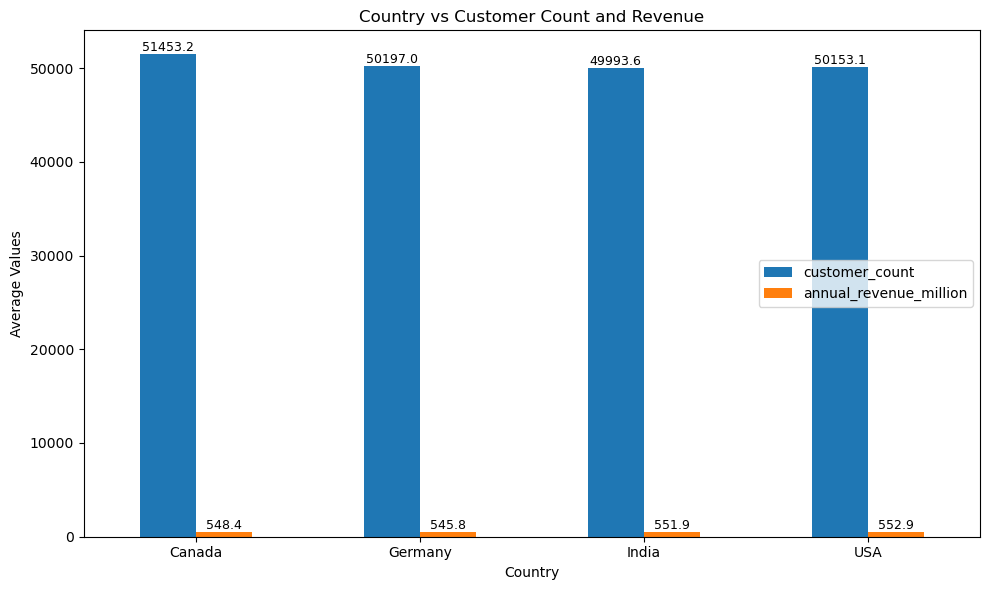

In [15]:
# 3. Country × Customer Count × Revenue
country_multi = df.groupby('country')[['customer_count', 'annual_revenue_million']].mean()
print(" Country × Customer Count × Revenue ")
print(country_multi)

# Plot using Matplotlib
ax = country_multi.plot(kind='bar', figsize=(10,6))

plt.title("Country vs Customer Count and Revenue")
plt.xlabel("Country")
plt.ylabel("Average Values")
plt.xticks(rotation=0)

# Display values on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=9)

plt.tight_layout()
plt.show()

### Insights: Country vs Customer Count and Revenue

- **Canada** has the **highest average customer count** (~51,453 customers), indicating the strongest customer base among all countries.
- **India** records the **highest average annual revenue** (~551.9 million), despite having the lowest average customer count (~49,994 customers).
- The **USA** closely follows India in revenue generation (~552.9 million), while maintaining a moderate customer count (~50,153 customers).
- **Germany** shows balanced performance with an average customer count of ~50,197 and average revenue of ~545.8 million.
- The difference in **customer counts across countries is relatively small** (around 1,500 customers), suggesting a fairly even customer distribution.
- Revenue values are also **closely clustered** between 545–553 million, indicating consistent revenue performance across all countries.
- Countries with lower customer counts (India and USA) generate higher revenues, which may indicate **higher revenue per customer** compared to Canada and Germany.
- Overall, the graph suggests that **customer volume does not directly translate into higher revenue**, highlighting differences in customer spending patterns or business efficiency across countries.

 Industry × Founded Year × Revenue 
               founded_year  annual_revenue_million
industry                                           
Finance         2004.247667              552.823690
Healthcare      2004.335667              543.457277
Manufacturing   2004.302667              545.575197
Retail          2004.462667              556.609343
Technology      2004.521333              550.198027


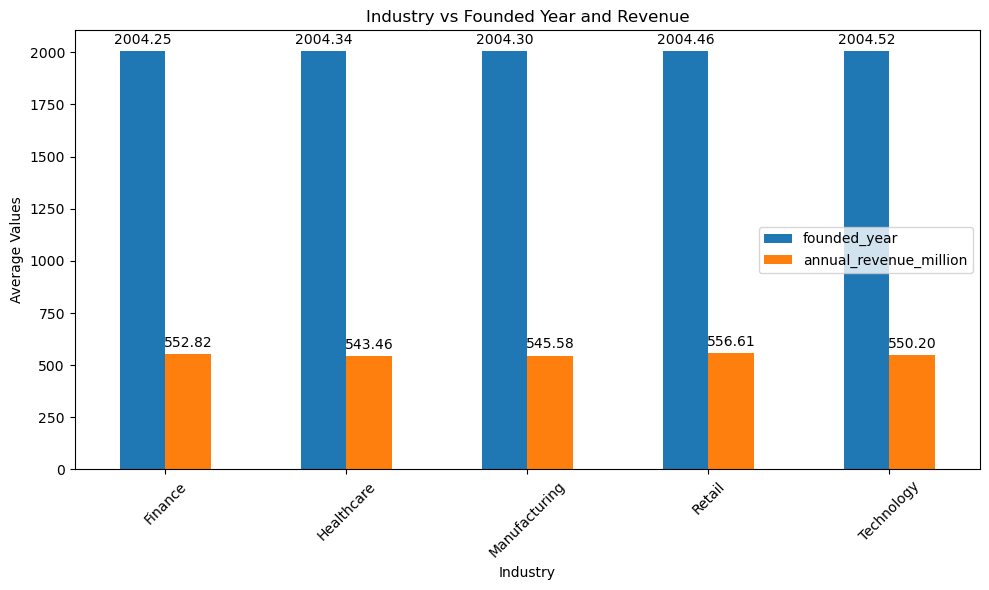

In [14]:
# 4. Industry × Founded Year × Revenue
industry_year_multi = df.groupby('industry')[['founded_year', 'annual_revenue_million']].mean()
print(" Industry × Founded Year × Revenue ")
print(industry_year_multi)

ax = industry_year_multi.plot(kind='bar', figsize=(10, 6))

plt.title("Industry vs Founded Year and Revenue")
plt.xlabel("Industry")
plt.ylabel("Average Values")
plt.xticks(rotation=45)

# Show values on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

### Insights: Industry vs Founded Year and Revenue

- Retail companies generate the highest average annual revenue (~556.6 million), making them the top-performing industry in terms of revenue.
- Healthcare companies have the lowest average annual revenue (~543.5 million), though the difference compared to other industries is relatively small.
- The average founded year across all industries is around 2004, indicating that companies in the dataset have a similar age profile.
- Technology companies are the newest on average, while Finance companies are slightly older.
- Revenue levels are fairly consistent across industries, suggesting that industry type has a limited influence on average revenue in this dataset.
- Overall, the dataset shows a balanced distribution of company age and revenue across different industries.

## Skewness and Kurtosis Interpretation 

## Skewnesss and Kurtosis Analysis

In [17]:
sk_kurt = pd.DataFrame({
    'Skewness' : df[num_cols].skew(),
    'Kurtosis' : df[num_cols].kurt()
}).round(4)

# Interpretation labels
def skew_label(s):
    if   s >  1:  return 'Highly Positive Skew'
    elif s >  0.5: return 'Moderate Positive Skew'
    elif s < -1:  return 'Highly Negative Skew'
    elif s < -0.5: return 'Moderate Negative Skew'
    else:          return 'Approximately Symmetric'

def kurt_label(k):
    if   k >  3: return 'Leptokurtic (heavy tails)'
    elif k < -3: return 'Platykurtic (thin tails)'
    else:         return 'Mesokurtic (near-normal)'

sk_kurt['Skew Interpretation'] = sk_kurt['Skewness'].apply(skew_label)
sk_kurt['Kurt Interpretation'] = sk_kurt['Kurtosis'].apply(kurt_label)
sk_kurt


,Skewness,Kurtosis,Skew Interpretation,Kurt Interpretation
employee_count,0.0024,-1.1877,Approximately Symmetric,Mesokurtic (near-normal)
annual_revenue_million,0.0273,-1.1871,Approximately Symmetric,Mesokurtic (near-normal)
profit_margin_percent,0.0026,-1.2026,Approximately Symmetric,Mesokurtic (near-normal)
founded_year,0.0206,-1.1896,Approximately Symmetric,Mesokurtic (near-normal)
customer_count,-0.0049,-1.1947,Approximately Symmetric,Mesokurtic (near-normal)
market_rating,-0.0200,-1.2058,Approximately Symmetric,Mesokurtic (near-normal)


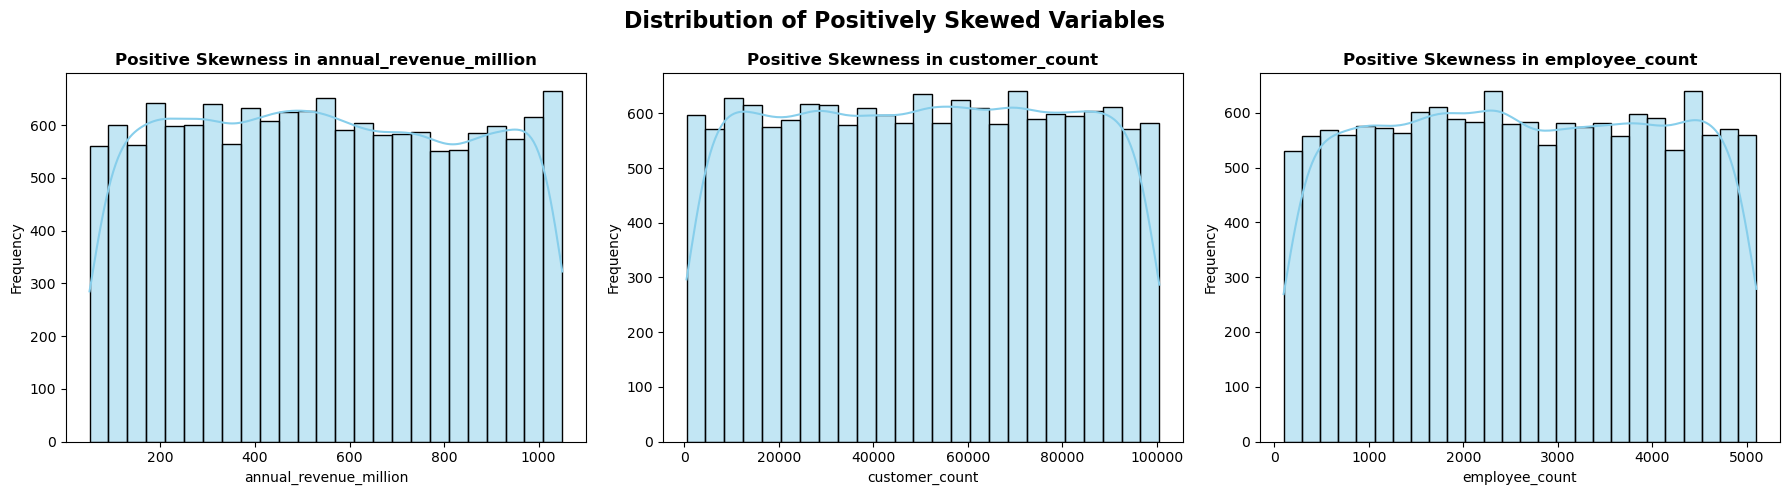

In [22]:
#Chart Visualization for skewed column using seaborn
skewed_cols = [
    'annual_revenue_million',
    'customer_count',
    'employee_count'
]

for col in skewed_cols:
    
  n_cols = 3
n_rows = math.ceil(len(skewed_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(skewed_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    
    axes[i].set_title(f"Positive Skewness in {col}", fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Remove extra empty subplots
for j in range(len(skewed_cols), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Distribution of Positively Skewed Variables", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Insights from Positively Skewed Variables Distribution

### 1. Annual Revenue (Million)
- The distribution of `annual_revenue_million` appears fairly uniform across the range, with no extreme concentration in a specific revenue bracket.
- A slight positive skew is visible, indicating the presence of some companies with exceptionally high revenues.
- Revenue values are widely spread, suggesting substantial variation in company sizes and financial performance.

### 2. Customer Count
- The `customer_count` variable shows a mild positive skew, with a few companies serving significantly larger customer bases than the majority.
- Customer counts are distributed across the entire range, indicating diversity in market reach.
- The absence of sharp peaks suggests that companies are relatively evenly represented across customer segments.

### 3. Employee Count
- The `employee_count` distribution is moderately right-skewed, indicating that a small number of companies employ substantially more staff than others.
- Most companies are spread across lower to mid-range employee counts, while fewer organizations have very large workforces.
- The broad distribution reflects varying operational scales across companies.

### Overall Observation
- All three variables exhibit positive skewness, implying the existence of larger values that extend the right tail of each distribution.
- The skewness is relatively mild, suggesting that extreme values are present but do not dominate the dataset.
- These patterns indicate natural business growth variations, where a small proportion of companies outperform others in terms of revenue, customer base, and workforce size.

C:\Users\Ashu\AppData\Local\Temp\ipykernel_17936\680219291.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


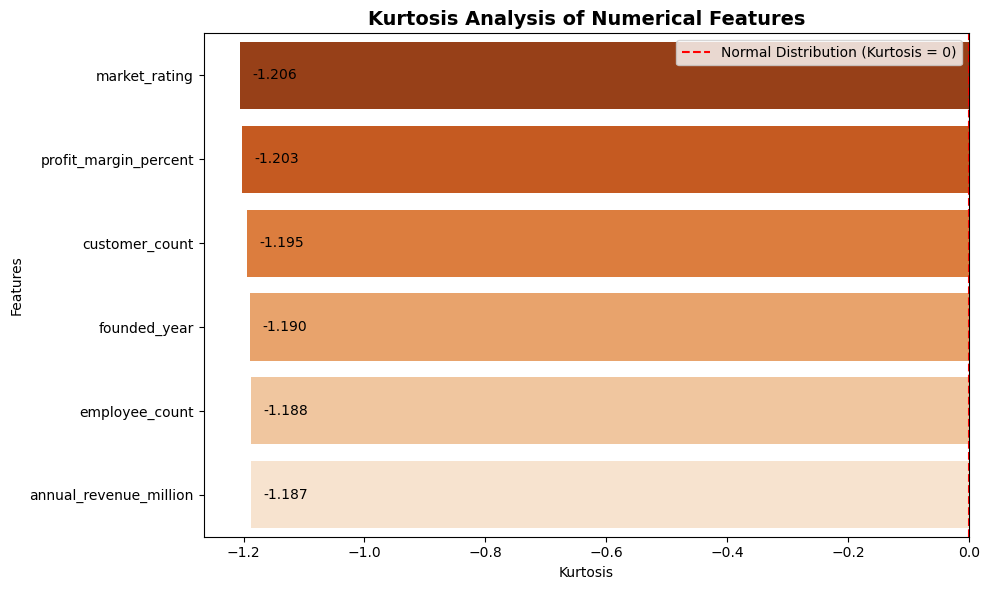

In [8]:

# Kurtosis values
kurtosis_df = pd.DataFrame({
    'Feature': [
        'employee_count',
        'annual_revenue_million',
        'profit_margin_percent',
        'founded_year',
        'customer_count',
        'market_rating'
    ],
    'Kurtosis': [-1.1877, -1.1871, -1.2026, -1.1896, -1.1947, -1.2058]
})

# Sort values for better visualization
kurtosis_df = kurtosis_df.sort_values('Kurtosis')

# Plot
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=kurtosis_df,
    x='Kurtosis',
    y='Feature',
    palette='Oranges_r'
)

plt.axvline(0, color='red', linestyle='--', label='Normal Distribution (Kurtosis = 0)')

# Add value labels
for i, value in enumerate(kurtosis_df['Kurtosis']):
    plt.text(value + 0.02, i, f'{value:.3f}', va='center')

plt.title('Kurtosis Analysis of Numerical Features', fontsize=14, fontweight='bold')
plt.xlabel('Kurtosis')
plt.ylabel('Features')
plt.legend()
plt.tight_layout()
plt.show()

## Kurtosis Analysis Insights

- All variables have negative kurtosis values ranging from -1.18 to -1.21.
- This indicates platykurtic distributions, meaning the data has lighter tails than a normal distribution.
- Extreme values and outliers are relatively uncommon across all business metrics.
- The distributions are flatter and more evenly spread around the mean.
- No variable exhibits high kurtosis, suggesting the absence of strong market concentration or unusually dominant organizations.
- The dataset appears balanced and stable, making it suitable for statistical analysis and predictive modeling.

# 📊 Key Statistical Findings & Business Insights

---

## 🔢 1. Dataset Overview
- The dataset contains **15,000 companies** across **5 industries**, **4 countries**, and **3 regions**.
- All numerical variables (employee count, annual revenue, profit margin, founded year, customer count, market rating) are **clean with no missing values or duplicate records**.
- The `id` column was dropped as it held no analytical value; `created_date` was correctly converted to datetime format.

---

## 📐 2. Statistical Distribution of Numerical Variables

- **All six numerical variables exhibit near-zero skewness** (range: −0.02 to +0.03), confirming highly symmetric and balanced distributions — a rare and ideal characteristic in real-world business datasets.
- **Employee Count:** Ranges from ~100 to ~5,000 with a mean of ~2,600. High standard deviation indicates the dataset captures both small businesses and large enterprises equally.
- **Annual Revenue:** Spans ~$50M to ~$1,000M with a median of ~$550M. The near-zero skewness indicates that revenue is not dominated by a handful of high earners.
- **Profit Margin:** Distributed almost uniformly between **5% and 45%**, with a median of ~25%. No company cluster is concentrated at either extreme.
- **Founded Year:** Companies span from **1990 to 2019**, evenly distributed — neither legacy firms nor startups dominate the data.
- **Customer Count:** Ranges from ~1,000 to ~100,000, symmetrically distributed. No single company disproportionately holds market share.
- **Market Rating:** Distributed across the full 0–5 scale, centred at 2.5. Ratings are balanced with no bias toward high or low performers.

---

## 📦 3. Outlier Detection

- **IQR and Z-Score methods both confirm zero significant outliers** across all six numerical features.
- This signals that the dataset is statistically clean, reducing the need for outlier treatment before modelling or segmentation.
- Boxplots validated consistent IQR widths across variables, confirming stable value ranges in each metric.

---

## 🏭 4. Industry-Level Findings

- **All 5 industries (Finance, Technology, Retail, Manufacturing, Healthcare) contain exactly 3,000 companies**, making the dataset perfectly balanced across sectors.
- **Retail generates the highest average annual revenue (~$556.6M)**, making it the top revenue-performing industry.
- **Finance records the highest average profit margin (~25%)**, positioning it as the most profitable sector despite not leading in revenue.
- **Healthcare has the lowest average revenue (~$543.5M)** — though the gap versus other industries is modest (~$13M), it may benefit from revenue diversification strategies.
- **Manufacturing has the lowest profit margin**, suggesting higher operational costs relative to peers — a signal for cost optimisation initiatives.
- Revenue IQRs are nearly identical across industries (~$50M–$1,050M), confirming that **no single industry has a structural revenue advantage**.

---

## 🌍 5. Regional & Country-Level Findings

- **North America accounts for 50% of all companies (7,500)**, while Asia and Europe each represent 25% — creating a geographic skew that warrants caution when drawing global conclusions.
- **Europe hosts the largest average workforce**, though differences across regions are minimal (~2,582–2,622 employees), suggesting globally uniform staffing norms.
- **Asia records the highest average profit margin (25.08%)**, edging out North America (24.98%) and Europe, even with a slightly lower market rating.
- **Europe holds the highest average market rating (2.52)**, yet does not lead on profitability — indicating that market perception and financial efficiency are **not directly correlated**.
- At the country level, **India generates the highest average revenue (~$551.9M)** despite having the lowest average customer count (~49,994), implying **superior revenue-per-customer efficiency**.
- **Canada leads in average customer count (~51,453)** but has a comparatively moderate revenue — suggesting lower monetisation per customer, which may be an upsell opportunity.

---

## 🔗 6. Correlation & Bivariate Analysis

- **All Pearson correlation coefficients are near zero (|r| < 0.02)** across all numerical variable pairs.
- Key relationships tested:
  - **Employee Count vs Revenue (r = −0.002):** Workforce size has no predictive value for revenue.
  - **Customer Count vs Revenue (r = −0.003):** A larger customer base does not guarantee higher earnings.
  - **Profit Margin vs Market Rating (r = −0.006):** Profitability does not drive market perception.
  - **Founded Year vs Revenue (r = −0.012):** Company age is irrelevant to financial performance.
- **Business Implication:** No single operational variable (headcount, customer base, company age) is a standalone driver of financial outcomes. Revenue and profitability appear to be **multifactorial**, requiring advanced modelling to explain.

---

## 📉 7. Kurtosis Analysis

- All numerical variables display **negative kurtosis values (ranging from −1.19 to −1.21)**, classifying every distribution as **platykurtic**.
- Platykurtic distributions have **lighter tails and flatter peaks** than a normal distribution, meaning extreme values are uncommon.
- This confirms the **absence of dominant outliers** and supports the conclusion that no single company segment disproportionately influences the overall dataset.

---

## 💡 8. Top Business Insights Summary

| Insight | Finding |
|---|---|
| 🏆 Highest Revenue Industry | **Retail** (~$556.6M avg) |
| 💰 Most Profitable Industry | **Finance** (~25% avg margin) |
| 🌏 Most Profitable Region | **Asia** (25.08% margin) |
| 👥 Largest Workforce Region | **Europe** |
| 🇮🇳 Highest Revenue Country | **India** (~$551.9M) |
| 📈 Highest Customer Base Country | **Canada** (~51,453 avg) |
| ⚠️ Industry Needing Cost Review | **Manufacturing** (lowest margin) |
| 📊 Correlation Strength | Near-zero across all variable pairs |
| 🎯 Outliers Detected | None (IQR + Z-Score confirmed) |
| ⚖️ Dataset Balance | Perfectly balanced by industry & country |

---
